In [1]:
import numpy as np
import pandas as pd

from statsmodels.tsa.api import ARIMA
from statsmodels.stats.api import het_arch, acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_predict

import pandas_datareader.data as web

# настройки визуализации
import matplotlib.pyplot as plt

# Не показывать Warnings
import warnings
warnings.simplefilter(action='ignore', category=Warning)
# Не показывать ValueWarning, ConvergenceWarning из statsmodels
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning
warnings.simplefilter('ignore', category=ValueWarning)
warnings.simplefilter('ignore', category=ConvergenceWarning)

# Вопрос 1

In [2]:
y = web.DataReader(name='WBAA', data_source='fred', start='2000-01-01', end='2025-12-31')
y

,WBAA
DATE,
2000-01-07,8.25
2000-01-14,8.37
2000-01-21,8.44
2000-01-28,8.29
2000-02-04,8.22
...,...
2025-11-28,5.80
2025-12-05,5.86
2025-12-12,5.90


In [3]:
# спецификация модели
mod = ARIMA(y, order=(2,0,1), trend='n', missing='drop')
# подгонка модели на данных
res = mod.fit()
# выводим результаты подгонки
res.summary(alpha=0.1)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   WBAA   No. Observations:                 1356
Model:                 ARIMA(2, 0, 1)   Log Likelihood                1292.713
Date:                Tue, 31 Mar 2026   AIC                          -2577.427
Time:                        22:36:54   BIC                          -2556.577
Sample:                    01-07-2000   HQIC                         -2569.620
                         - 12-26-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|       [0.05       0.95]
------------------------------------------------------------------------------
ar.L1          1.2449      0.056     22.431      0.000       1.154       1.336
ar.L2         -0.2451      0.056     -4.413      0.000      -0.336      -0.154
ma.L1          0.0449      0.055      0.814      0.416      -0.046       0.136
sigma2         0.0086      0.000     45.639      0.000       0.008       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3921.40
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               1.64   Skew:                             0.80
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.17
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [4]:
# корректировка степеней свободы: число оцениваемых коэффициентов = число параметров - 1 (-sigma2)
model_df = mod.k_params-1
# для тест отбрасываем первые d остатков (d=mod.k_diff)
acorr_ljungbox(res.resid[mod.k_diff:] , lags=[5], model_df=model_df)

,lb_stat,lb_pvalue
5,0.45929,0.794816


arima-statsmodels.ipynb

# Вопрос 2

In [5]:
y = np.log(web.DataReader(name='WAAA', data_source='fred', start='2010-01-01', end='2025-12-31'))
y

,WAAA
DATE,
2010-01-01,1.675226
2010-01-08,1.667707
2010-01-15,1.656321
2010-01-22,1.652497
2010-01-29,1.663926
...,...
2025-11-28,1.648659
2025-12-05,1.658228
2025-12-12,1.669592


In [6]:
from statsmodels.tsa.api import adfuller, kpss, range_unit_root_test

In [7]:
adf_stat, pval, usedlag, nobs, critical_values, BIC = adfuller(y, regression='ct', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat, pval, critical_values

(np.float64(-1.6860881039804752),
 np.float64(0.7569355294851438),
 {'1%': np.float64(-3.9696924303751246),
  '5%': np.float64(-3.415780055438785),
  '10%': np.float64(-3.130163401296457)})

p-value>0.05. Ряд нестационарен. Нужно дифф

In [8]:
adf_stat, pval, usedlag, nobs, critical_values, BIC = adfuller(y.diff().dropna(), regression='c', autolag='BIC')
# тестовая статистика, её p-значение и критические значения
adf_stat, pval, critical_values

(np.float64(-21.065976018332822),
 0.0,
 {'1%': np.float64(-3.4382341228740345),
  '5%': np.float64(-2.865020104308721),
  '10%': np.float64(-2.568623096396542)})

p-value<0.05. Ряд стационарен. d = 1

ur-tests-statsmodels.ipynb

In [9]:
# импорт из пакета pmdarima
from sktime.forecasting.arima import AutoARIMA

from sktime.utils.plotting import plot_series
# временной горизонт для прогнозирования
from sktime.forecasting.base import ForecastingHorizon

In [10]:
forecaster = AutoARIMA(information_criterion='bic', test='adf', seasonal=False)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'ma.L1': np.float64(0.21656461851826203),
 'ma.L2': np.float64(-0.10148124095270708),
 'sigma2': np.float64(0.0006053454840656387),
 'order': (0, 1, 2),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-3806.7788993034587),
 'aicc': np.float64(-3806.7499836408083),
 'bic': np.float64(-3792.6001990963823),
 'hqic': np.float64(-3801.3428074181006)}

autoarima-sktime.ipynb

# Вопрос 3

In [11]:
y = web.DataReader(name='WAAA', data_source='fred', start='2000-01-01', end='2025-12-31').diff()
y

,WAAA
DATE,
2000-01-07,NaN
2000-01-14,0.07
2000-01-21,0.08
2000-01-28,-0.15
2000-02-04,-0.08
...,...
2025-11-28,-0.10
2025-12-05,0.05
2025-12-12,0.06


In [12]:
from statsmodels.tsa.api import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [14]:
acf(y, nlags=2, missing = 'drop').round(3)

array([ 1.   ,  0.189, -0.023])

In [15]:
pacf(y, nlags=2).round(3)

array([ 1., nan, nan])

sample-acf-pacf-statsmodels.ipynb

# Вопрос 5

In [16]:
y = web.DataReader(name='MORTGAGE30US', data_source='fred', start='2000-01-01', end='2025-12-31')
y

,MORTGAGE30US
DATE,
2000-01-07,8.15
2000-01-14,8.18
2000-01-21,8.26
2000-01-28,8.25
2000-02-04,8.25
...,...
2025-12-04,6.19
2025-12-11,6.22
2025-12-18,6.21


In [17]:
# спецификация модели
mod = ARIMA(y, order=(2,1,2), trend='n', missing='drop')
# подгонка модели на данных
res = mod.fit()
# выводим результаты подгонки
res.summary(alpha=0.1)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:           MORTGAGE30US   No. Observations:                 1357
Model:                 ARIMA(2, 1, 2)   Log Likelihood                1270.032
Date:                Tue, 31 Mar 2026   AIC                          -2530.064
Time:                        22:37:54   BIC                          -2504.002
Sample:                             0   HQIC                         -2520.306
                               - 1357                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|       [0.05       0.95]
------------------------------------------------------------------------------
ar.L1         -0.3691      0.096     -3.845      0.000      -0.527      -0.211
ar.L2          0.4579      0.095      4.835      0.000       0.302       0.614
ma.L1          0.4678      0.102      4.584      0.000       0.300       0.636
ma.L2         -0.3065      0.100     -3.065      0.002      -0.471      -0.142
sigma2         0.0090      0.000     45.021      0.000       0.009       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              1214.78
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.19   Skew:                             0.53
Prob(H) (two-sided):                  0.07   Kurtosis:                         7.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

ar = ф

arima-statsmodels.ipynb

# Вопрос 6

In [20]:
y = web.DataReader(name='WBAA', data_source='fred', start='2000-01-01', end='2025-12-31').diff().dropna()
y

,WBAA
DATE,
2000-01-14,0.12
2000-01-21,0.07
2000-01-28,-0.15
2000-02-04,-0.07
2000-02-11,0.08
...,...
2025-11-28,-0.10
2025-12-05,0.06
2025-12-12,0.04


In [21]:
kpss_stat, p_value, lags, crit = kpss(y, regression='ct')
# тестовая статистика, её p-значение и критические значения
kpss_stat, p_value, crit

(np.float64(0.033474648557809794),
 np.float64(0.1),
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

p-value < 0.05. Ряд нестационарен. Есть един корень. Нужно дифф

ur-tests-statsmodels.ipynb

# Вопрос 7

In [22]:
y = web.DataReader(name='WBAA ', data_source='fred', start='2000-01-01', end='2025-12-31')
y

,WBAA
DATE,
2000-01-07,8.25
2000-01-14,8.37
2000-01-21,8.44
2000-01-28,8.29
2000-02-04,8.22
...,...
2025-11-28,5.80
2025-12-05,5.86
2025-12-12,5.90


In [23]:
# спецификация модели
mod = ARIMA(y, order=(1,2,1), trend='n', missing='drop')
# подгонка модели на данных
res = mod.fit()
# выводим результаты подгонки
res.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  WBAA    No. Observations:                 1356
Model:                 ARIMA(1, 2, 1)   Log Likelihood                1291.325
Date:                Tue, 31 Mar 2026   AIC                          -2576.649
Time:                        22:39:03   BIC                          -2561.017
Sample:                    01-07-2000   HQIC                         -2570.796
                         - 12-26-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2869      0.020     14.248      0.000       0.247       0.326
ma.L1         -1.0000      0.359     -2.786      0.005      -1.704      -0.296
sigma2         0.0086      0.003      2.787      0.005       0.003       0.015
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              3890.53
Prob(Q):                              0.91   Prob(JB):                         0.00
Heteroskedasticity (H):               1.65   Skew:                             0.78
Prob(H) (two-sided):                  0.00   Kurtosis:                        11.16
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [24]:
forecasts = res.forecast(steps=2)
forecasts.round(3)

2026-01-02    5.890
2026-01-09    5.886
Freq: W-FRI, Name: predicted_mean, dtype: float64

arima-statsmodels.ipynb

# Вопрос 1

In [25]:
y = web.DataReader(name='WAAA', data_source='fred', start='2000-01-01', end='2025-12-31')
y

,WAAA
DATE,
2000-01-07,7.73
2000-01-14,7.80
2000-01-21,7.88
2000-01-28,7.73
2000-02-04,7.65
...,...
2025-11-28,5.20
2025-12-05,5.25
2025-12-12,5.31


In [26]:
# спецификация модели
mod = ARIMA(y, order=(1,0,3), trend='n', missing='drop')
# подгонка модели на данных
res = mod.fit()
# выводим результаты подгонки
res.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   WAAA   No. Observations:                 1356
Model:                 ARIMA(1, 0, 3)   Log Likelihood                1303.484
Date:                Tue, 31 Mar 2026   AIC                          -2596.968
Time:                        22:40:23   BIC                          -2570.906
Sample:                    01-07-2000   HQIC                         -2587.210
                         - 12-26-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9993      0.000   4369.488      0.000       0.999       1.000
ma.L1          0.2061      0.014     14.908      0.000       0.179       0.233
ma.L2         -0.0189      0.016     -1.170      0.242      -0.051       0.013
ma.L3          0.0148      0.021      0.706      0.480      -0.026       0.056
sigma2         0.0085      0.000     54.049      0.000       0.008       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              2892.89
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.56   Skew:                             0.28
Prob(H) (two-sided):                  0.00   Kurtosis:                        10.13
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [27]:
forecasts = res.forecast(steps=2)
forecasts.round(3)

2026-01-02    5.312
2026-01-09    5.309
Freq: W-FRI, Name: predicted_mean, dtype: float64

# Вопрос 2

In [29]:
# спецификация модели
mod = ARIMA(y, order=(3,2,3), trend='n', missing='drop')
# подгонка модели на данных
res = mod.fit()
# выводим результаты подгонки
res.summary(alpha=0.05)

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                   WAAA   No. Observations:                 1356
Model:                 ARIMA(3, 2, 3)   Log Likelihood                1310.192
Date:                Tue, 31 Mar 2026   AIC                          -2606.385
Time:                        22:41:52   BIC                          -2569.909
Sample:                    01-07-2000   HQIC                         -2592.726
                         - 12-26-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.3448      0.079    -16.969      0.000      -1.500      -1.189
ar.L2         -0.5383      0.066     -8.160      0.000      -0.668      -0.409
ar.L3          0.0724      0.029      2.487      0.013       0.015       0.129
ma.L1          0.5580      0.079      7.036      0.000       0.403       0.713
ma.L2         -0.7682      0.045    -17.118      0.000      -0.856      -0.680
ma.L3         -0.7842      0.078    -10.033      0.000      -0.937      -0.631
sigma2         0.0084      0.000     49.414      0.000       0.008       0.009
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              2635.61
Prob(Q):                              0.95   Prob(JB):                         0.00
Heteroskedasticity (H):               1.57   Skew:                             0.30
Prob(H) (two-sided):                  0.00   Kurtosis:                         9.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

ma.L1	0.5580	
ma.L2	-0.7682

# Вопрос 3

In [30]:
y = web.DataReader(name='MORTGAGE30US', data_source='fred', start='2010-01-01', end='2025-12-31')
y

,MORTGAGE30US
DATE,
2010-01-07,5.09
2010-01-14,5.06
2010-01-21,4.99
2010-01-28,4.98
2010-02-04,5.01
...,...
2025-12-04,6.19
2025-12-11,6.22
2025-12-18,6.21


In [31]:
forecaster = AutoARIMA(information_criterion='aicc', test='adf', seasonal=False, max_p=3, max_q=3)
forecaster.fit(y)
forecaster.get_fitted_params() #['order']

{'ar.L1': np.float64(-0.5394089126273865),
 'ar.L2': np.float64(0.19572932222133116),
 'ma.L1': np.float64(0.6796170267356051),
 'sigma2': np.float64(0.007891613969289179),
 'order': (2, 1, 1),
 'seasonal_order': (0, 0, 0, 0),
 'aic': np.float64(-1663.2324865361538),
 'aicc': np.float64(-1663.1842356314494),
 'bic': np.float64(-1644.327552926719),
 'hqic': np.float64(-1655.984364022343)}

# Вопрос 4

In [33]:
y = web.DataReader(name='WBAA', data_source='fred', start='2000-01-01', end='2025-12-31').diff().dropna()
y

,WBAA
DATE,
2000-01-14,0.12
2000-01-21,0.07
2000-01-28,-0.15
2000-02-04,-0.07
2000-02-11,0.08
...,...
2025-11-28,-0.10
2025-12-05,0.06
2025-12-12,0.04


In [34]:
acf(y, nlags=1, missing = 'drop').round(3)

array([1.   , 0.286])

In [35]:
pacf(y, nlags=1).round(3)

array([1.   , 0.286])

# Вопрос 5

In [36]:
from sktime.forecasting.arch import ARCH
from sktime.utils.plotting import plot_series
# временной горизонт для прогнозирования
from sktime.forecasting.base import ForecastingHorizon

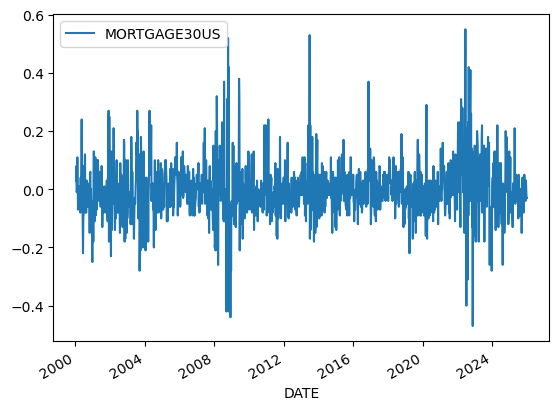

In [37]:
rate = web.DataReader(name='MORTGAGE30US', data_source='fred', start='2000-01-01', end='2025-12-31')
y = rate.diff().dropna()

y.plot()
plt.show()

In [38]:
forecaster = ARCH(mean='AR', lags=1, vol='GARCH', p=2, o = 1, q=2, power=2)  
forecaster.fit(y)

forecaster.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                         AR - GJR-GARCH Model Results                         
==============================================================================
Dep. Variable:                   None   R-squared:                       0.008
Mean Model:                        AR   Adj. R-squared:                  0.008
Vol Model:                  GJR-GARCH   Log-Likelihood:                1440.53
Distribution:                  Normal   AIC:                          -2865.07
Method:            Maximum Likelihood   BIC:                          -2823.38
                                        No. Observations:                 1355
Date:                Tue, Mar 31 2026   Df Residuals:                     1353
Time:                        22:50:19   Df Model:                            2
                                  Mean Model                                  
==============================================================================
                  coef    std err          t      P>|t|       95.0% Conf. Int.
------------------------------------------------------------------------------
Const      -2.0655e-03  2.129e-03     -0.970      0.332 [-6.238e-03,2.107e-03]
None[1]         0.1544  3.419e-02      4.516  6.293e-06    [8.740e-02,  0.221]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      6.2445e-04  3.125e-04      1.998  4.569e-02 [1.195e-05,1.237e-03]
alpha[1]       0.2452  6.947e-02      3.530  4.156e-04     [  0.109,  0.381]
alpha[2]       0.0405  8.324e-02      0.487      0.626     [ -0.123,  0.204]
gamma[1]      -0.1713  8.328e-02     -2.056  3.975e-02  [ -0.334,-8.030e-03]
beta[1]        0.2711      0.311      0.872      0.383     [ -0.338,  0.880]
beta[2]        0.4559      0.256      1.784  7.439e-02  [-4.490e-02,  0.957]
============================================================================

Covariance estimator: robust
"""

In [39]:
forecaster.get_fitted_params()

{'Const': np.float64(-0.0020655028559307736),
 'None[1]': np.float64(0.15441363263132982),
 'omega': np.float64(0.0006244524791213731),
 'alpha[1]': np.float64(0.24523981777508347),
 'alpha[2]': np.float64(0.04051071773687362),
 'gamma[1]': np.float64(-0.17125423011719876),
 'beta[1]': np.float64(0.27108114914314146),
 'beta[2]': np.float64(0.45588749763885517)}

garch-sktime.ipynb

# Вопрос 7

In [41]:
y = web.DataReader(name='WBAA', data_source='fred', start='2000-01-01', end='2025-12-31')
y

,WBAA
DATE,
2000-01-07,8.25
2000-01-14,8.37
2000-01-21,8.44
2000-01-28,8.29
2000-02-04,8.22
...,...
2025-11-28,5.80
2025-12-05,5.86
2025-12-12,5.90


In [42]:
kpss_stat, p_value, lags, crit = kpss(y, regression='ct')
# тестовая статистика, её p-значение и критические значения
kpss_stat, p_value, crit

(np.float64(0.5897184115945112),
 np.float64(0.01),
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

p-value < 0.05. Ряд нестационарен. Есть един корень. Нужно дифф